In [41]:
%load_ext aiida
%aiida

The aiida extension is already loaded. To reload it, use:
  %reload_ext aiida


Loaded AiiDA DB environment - profile name: bit.

In [42]:
import matplotlib.pyplot as plt
%matplotlib inline

In [43]:
from aiida import orm
from monty.serialization import loadfn, dumpfn
import numpy as np
from aiida_vasp.workchains import VaspHybridBandsWorkChain
from aiida_vasp.workchains.v2 import VaspHybridBandUpdater, VaspRelaxUpdater
from aiida_grouppathx import GroupPathX
from tqdm import tqdm
from aiida_grouppathx import GroupPathX

from aiida_user_addons.tools.sumo import get_sumo_bands_plotter, get_pmg_bandstructure

import pandas as pd

from aiida_vasp.utils.compare_bands import get_band_properties_from_data

In [44]:
basepath = GroupPathX('hc-binary-hse-abacus')
workpath = basepath['bandstructure_works']
nodes = [path.get_node() for path in workpath]
finished_ok = list(filter(lambda x: x.is_finished_ok, nodes)) 

In [45]:
def show_bands(worknode):
    plotter = get_sumo_bands_plotter(worknode.outputs.band_structure, structure=worknode.outputs.primitive_structure)
    return plotter

In [46]:
records = []
for node in tqdm(finished_ok):
    bs = get_pmg_bandstructure(node.outputs.band_structure, node.outputs.primitive_structure)
    band_info = bs.get_band_gap()  # Using pymatgen band gap information which is more robust than that shipped in AiiDA vasp
    band_info['band_gap'] = band_info.pop('energy')
    out_dict =     {
        'structure': node.inputs.structure.get_pymatgen(),
        'formula': node.inputs.structure.get_formula(),
        'material_id': node.label.split()[0],
        'uuid': node.uuid,
    }
    out_dict.update(band_info)
    records.append(
        out_dict
)
df = pd.DataFrame.from_records(records)   

100%|██████████████████████████████████████████████████████████████████████████████| 519/519 [00:17<00:00, 30.13it/s]


In [47]:
df[df.direct == True].sort_values('band_gap')

,structure,formula,material_id,uuid,direct,transition,band_gap
60,"[[0. 0. 0.] Ge, [4.00252088 2.31085652 1.63374...",GeSe,wbm-20074,241233a9-edc2-46bb-90f0-14932931e6fa,True,L-L,0.20136
516,"[[-1.00045274 -1.00045274 1.41499368] Ge, [1....",GeSe,wbm-20072,1df2ad56-5287-4d59-acc0-f020fa25c1fd,True,L-L,0.20183
5,"[[0. 0. 0.] Ga, [1.25275264 0.88582964 2.16983...",GaSb,mp-1156,83289504-663a-4cb7-b2a0-d57204658193,True,\Gamma-\Gamma,0.25945
11,"[[-3.09500995 -3.29645023 1.51262885] Se, [-1...",SeSn,wbm-107127,4302ca6b-43c0-436a-ad8e-5810df1502c3,True,L_2-L_2,0.26074
13,"[[-0.81023595 1.96013787 3.29608906] Sn, [ 0...",SnTe,wbm-56490,919daaf7-b30c-4307-8464-e42c28e2e595,True,L-L,0.40261
499,"[[1.13122007 1.13122007 1.5998032 ] Sn, [3.393...",SnTe,wbm-56489,f3acef76-93e9-44f4-be8c-581dc6dfebb1,True,L-L,0.40268
500,"[[4.52684582 2.61357565 1.84796032] Te, [0. 0....",SnTe,wbm-56493,f12ecfd8-e717-4179-ac57-27a2f2a0ed37,True,L-L,0.40276
21,"[[0. 0. 0.] Sn, [2.60120575 1.83933005 4.50542...",SnTe,mp-1883,52f294a1-e337-4cf1-9d47-c6f8675cd188,True,L-L,0.41663
36,"[[4.52226069 2.61092843 1.66589871] Te, [2.261...",SnTe,wbm-56491,59131d23-e61f-4875-bfc0-93de3bb7a079,True,L-L,0.52977
24,"[[0. 0. 0.] Ga, [1.173751 0.82996725 2.03299...",AsGa,mp-2534,50398d78-bc2a-4209-876b-717cb7dbb08e,True,\Gamma-\Gamma,0.61736


In [48]:
df[df.direct == True].sort_values('band_gap')

,structure,formula,material_id,uuid,direct,transition,band_gap
60,"[[0. 0. 0.] Ge, [4.00252088 2.31085652 1.63374...",GeSe,wbm-20074,241233a9-edc2-46bb-90f0-14932931e6fa,True,L-L,0.20136
516,"[[-1.00045274 -1.00045274 1.41499368] Ge, [1....",GeSe,wbm-20072,1df2ad56-5287-4d59-acc0-f020fa25c1fd,True,L-L,0.20183
5,"[[0. 0. 0.] Ga, [1.25275264 0.88582964 2.16983...",GaSb,mp-1156,83289504-663a-4cb7-b2a0-d57204658193,True,\Gamma-\Gamma,0.25945
11,"[[-3.09500995 -3.29645023 1.51262885] Se, [-1...",SeSn,wbm-107127,4302ca6b-43c0-436a-ad8e-5810df1502c3,True,L_2-L_2,0.26074
13,"[[-0.81023595 1.96013787 3.29608906] Sn, [ 0...",SnTe,wbm-56490,919daaf7-b30c-4307-8464-e42c28e2e595,True,L-L,0.40261
499,"[[1.13122007 1.13122007 1.5998032 ] Sn, [3.393...",SnTe,wbm-56489,f3acef76-93e9-44f4-be8c-581dc6dfebb1,True,L-L,0.40268
500,"[[4.52684582 2.61357565 1.84796032] Te, [0. 0....",SnTe,wbm-56493,f12ecfd8-e717-4179-ac57-27a2f2a0ed37,True,L-L,0.40276
21,"[[0. 0. 0.] Sn, [2.60120575 1.83933005 4.50542...",SnTe,mp-1883,52f294a1-e337-4cf1-9d47-c6f8675cd188,True,L-L,0.41663
36,"[[4.52226069 2.61092843 1.66589871] Te, [2.261...",SnTe,wbm-56491,59131d23-e61f-4875-bfc0-93de3bb7a079,True,L-L,0.52977
24,"[[0. 0. 0.] Ga, [1.173751 0.82996725 2.03299...",AsGa,mp-2534,50398d78-bc2a-4209-876b-717cb7dbb08e,True,\Gamma-\Gamma,0.61736


In [49]:
df[df.formula == 'InSb'].sort_values('band_gap')

,structure,formula,material_id,uuid,direct,transition,band_gap
497,"[[0. 0. 0.] In, [1.35400075 0.957423 2.34519...",InSb,mp-20012,7f2cf5fa-17e2-4f26-975b-32d41adf1d3e,False,None,0.0


<module 'matplotlib.pyplot' from '/home/bonan/miniconda3/envs/aiida/lib/python3.12/site-packages/matplotlib/pyplot.py'>

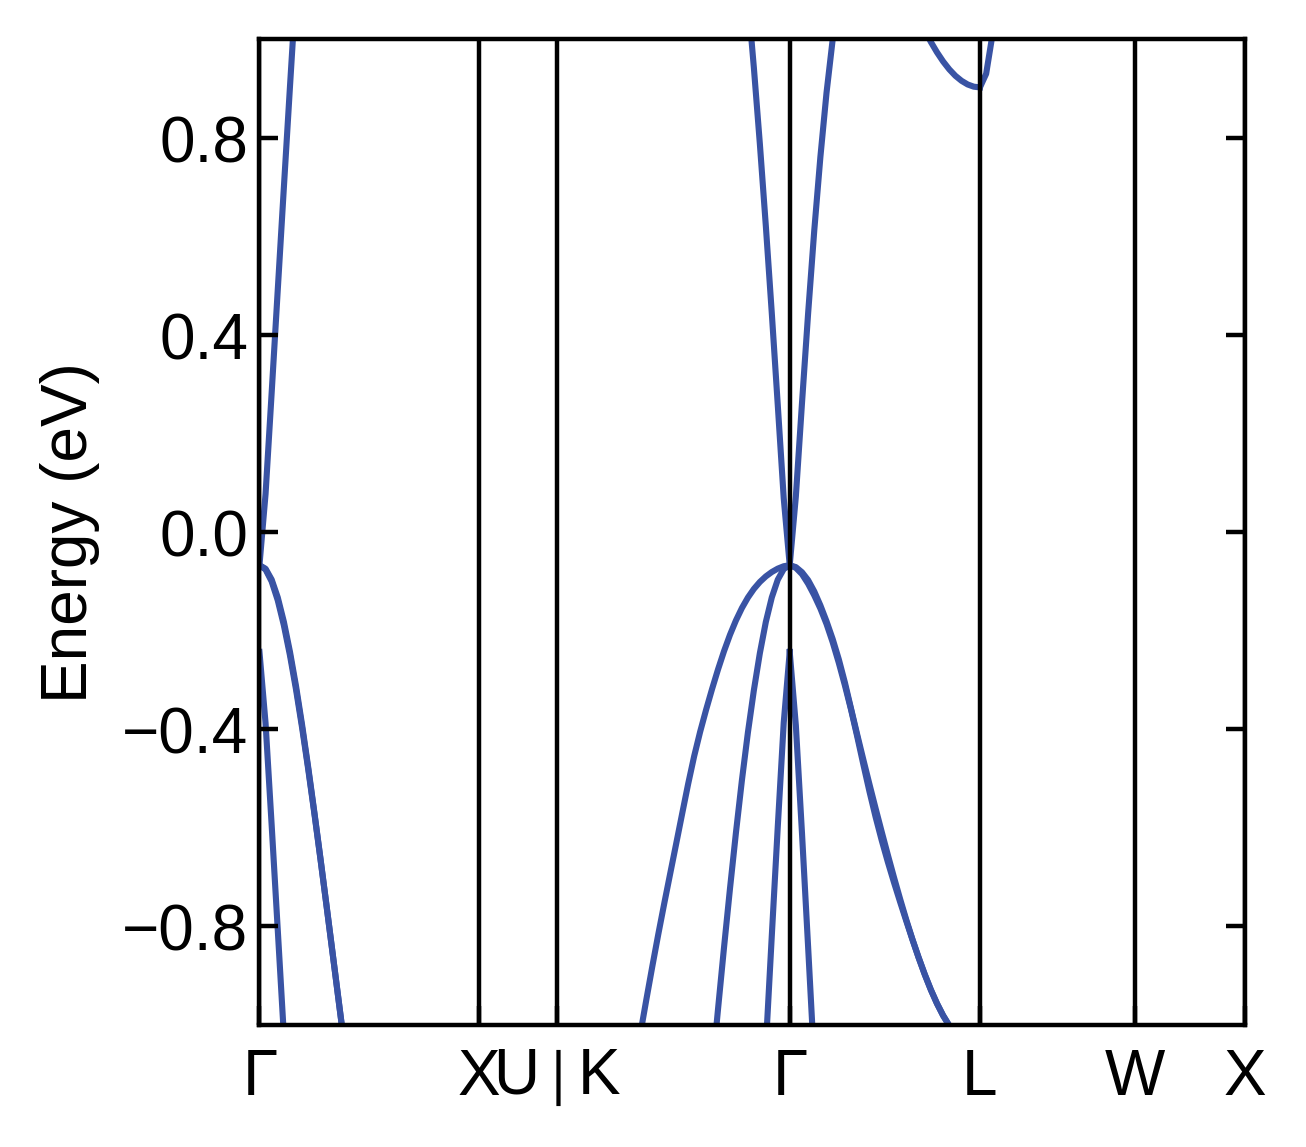

In [50]:
show_bands(load_node('7f2cf5fa-17e2-4f26-975b-32d41adf1d3e')).get_plot(ymin=-1, ymax=1)

In [32]:
#df.pop('structure', None)

df = df.sort_values('band_gap')
df.drop(['structure'], axis=1).to_csv('abacus_hse_gaps_binary_2025_0528_pmg_info.csv')